# 03 — Exploratory Data Analysis (EDA) Olist (Phase 4)

Ce notebook explore `data/processed/olist_customers_clean.csv` (93 358 clients, produit par la Phase 3) a l'aide des fonctions reutilisables de `src/eda/analysis.py` et des KPI de `src/eda/insights.py`.

**Questions business posees :**
1. Les clients reviennent-ils acheter une deuxieme fois (retention) ?
2. Combien depensent-ils, et cette depense varie-t-elle selon l'etat ?
3. Sont-ils satisfaits (review score), et la satisfaction varie-t-elle selon la categorie de produit ou le nombre de commandes ?
4. Ou sont-ils situes geographiquement, et ces metriques sont-elles correlees entre elles ?

**Aucune feature ML n'est calculee ici** (pas de colonne churn, pas de RFM) : ce sera l'objet de la Phase 5.

## 1. Chargement des donnees

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Le notebook est exécuté depuis notebooks/, donc la racine du projet est le
# dossier parent. On l'ajoute à sys.path pour pouvoir importer src.eda comme
# un package, exactement comme le font analysis.py et insights.py.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.eda import analysis, insights

customers_df = analysis.load_customers_clean()
print("Shape :", customers_df.shape)
customers_df.head()

Shape : (93358, 8)


,customer_unique_id,total_orders,total_spent,avg_review_score,first_order_date,last_order_date,most_frequent_category,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,5.0,2018-05-10 10:56:27,2018-05-10 10:56:27,bed_bath_table,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,2018-05-07 11:11:27,2018-05-07 11:11:27,health_beauty,SP
2,0000f46a3911fa3c0805444483337064,1,86.22,3.0,2017-03-10 21:05:03,2017-03-10 21:05:03,stationery,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,4.0,2017-10-12 20:29:41,2017-10-12 20:29:41,telephony,PA
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,5.0,2017-11-14 19:45:42,2017-11-14 19:45:42,telephony,SP


## 2. KPI business

In [2]:
kpis = insights.compute_kpis(customers_df)
print(insights.format_report(kpis))

KPI BUSINESS - Olist (dataset client agrege, Phase 4 EDA)
Date du rapport : 2026-07-24T12:58:03
Date de reference (max last_order_date) : 2018-08-29

% clients avec exactement 1 commande : 97.00%
% clients churned (recency > 180 jours depuis la date de reference) : 58.92%
Montant median depense (total_spent) : 113.14
Score de satisfaction moyen (avg_review_score) : 4.16

Top 3 categories les plus achetees :
  - bed_bath_table: 8899 clients
  - health_beauty: 8369 clients
  - sports_leisure: 7139 clients

Top 3 etats par nombre de clients :
  - SP: 39150 clients
  - RJ: 11913 clients
  - MG: 10996 clients

Nombre de clients par segment de depense :
  - low: 15223 clients
  - medium: 54448 clients
  - high: 16687 clients
  - very_high: 7000 clients


## 3. Bloc 1 — Retention

Distribution du nombre de commandes par client, et courbe de retention cumulative (% de clients avec N commandes ou plus).

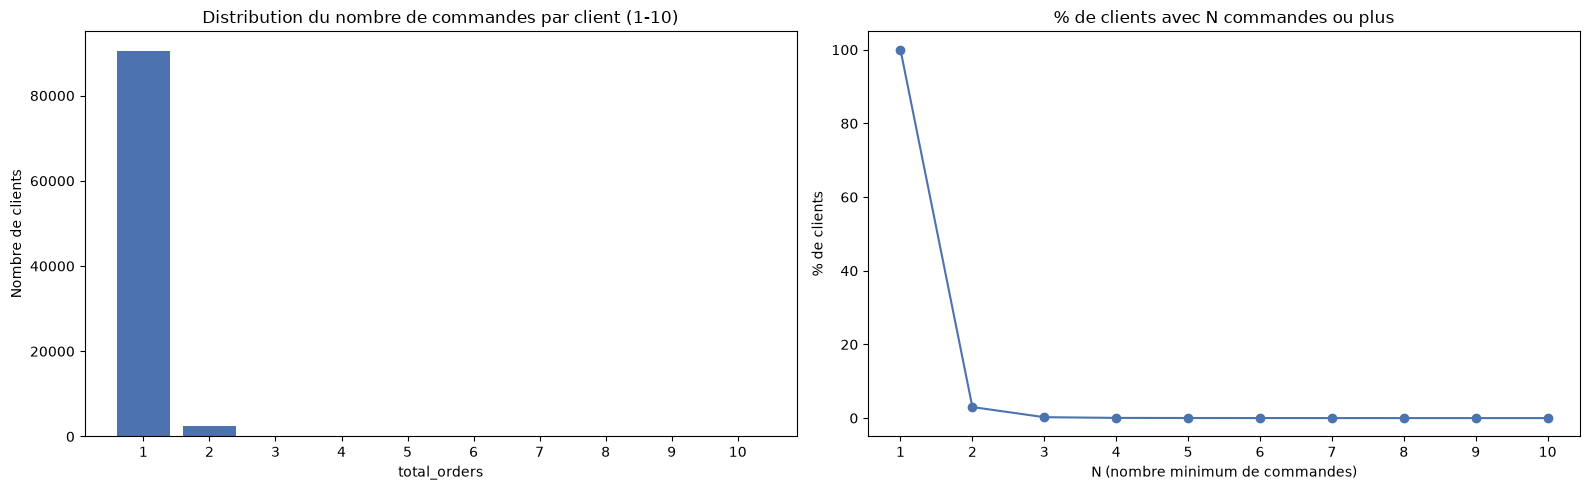

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
analysis.plot_orders_distribution(customers_df, ax=axes[0])
analysis.plot_retention_curve(customers_df, ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Bloc 2 — Analyse monetaire

Distribution de la depense totale par client (echelle log), et comparaison de cette depense entre le top 5 des etats par nombre de clients.

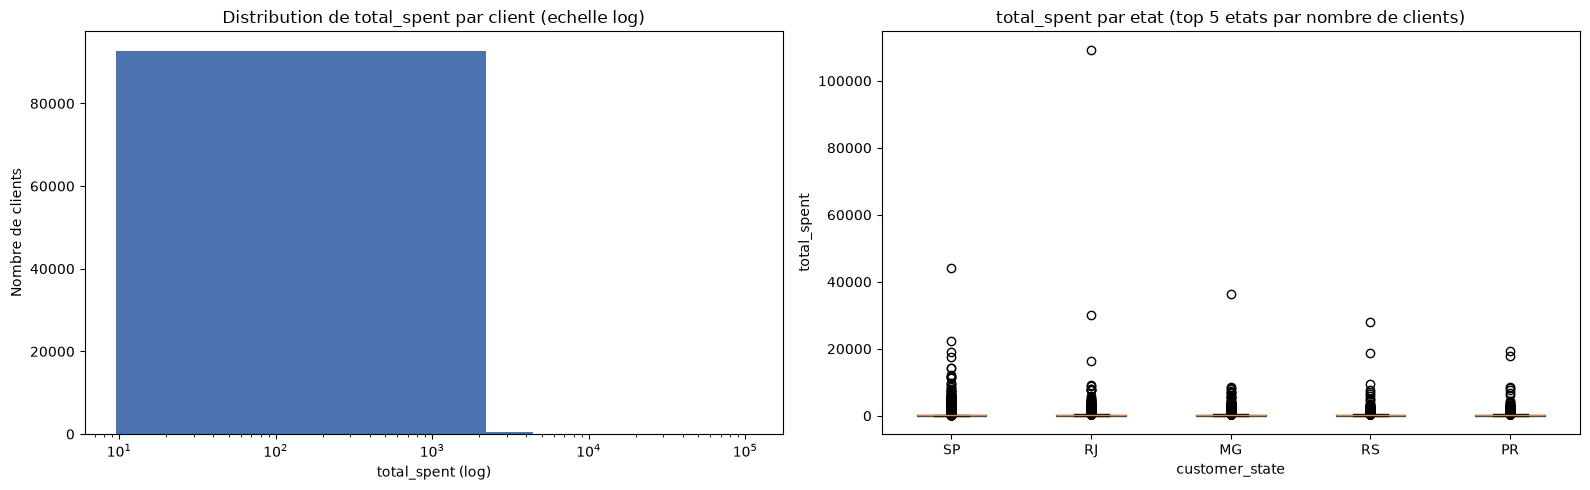

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
analysis.plot_spent_distribution(customers_df, ax=axes[0])
analysis.plot_spent_by_state(customers_df, ax=axes[1])
plt.tight_layout()
plt.show()

## 5. Bloc 3 — Analyse de la satisfaction

Distribution des scores de review, score moyen par categorie de produit, et relation entre satisfaction et nombre de commandes.

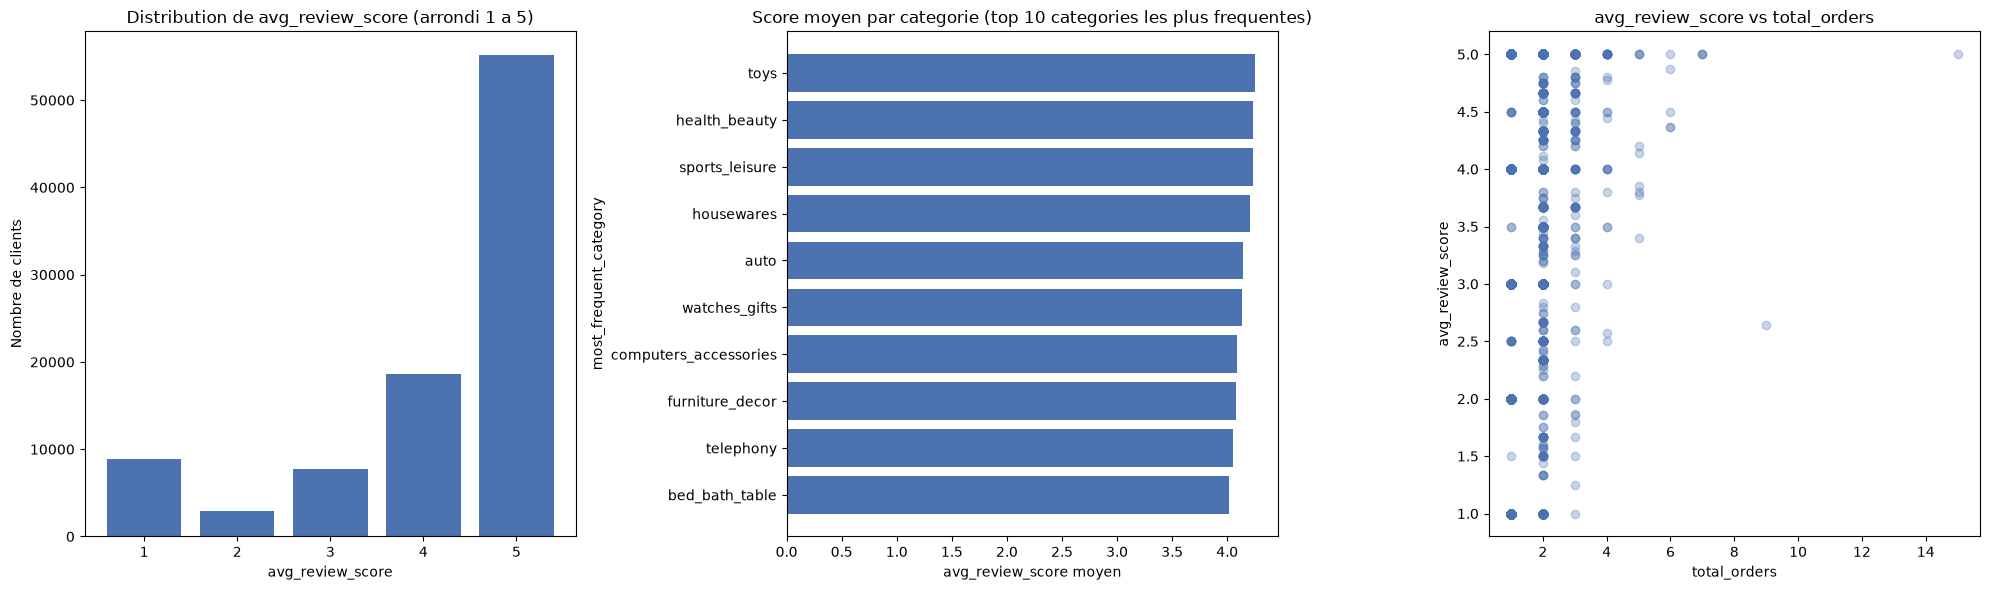

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
analysis.plot_review_distribution(customers_df, ax=axes[0])
analysis.plot_review_by_category(customers_df, ax=axes[1])
analysis.plot_review_vs_orders(customers_df, ax=axes[2])
plt.tight_layout()
plt.show()

## 6. Bloc 4 — Geographie et correlations

Repartition des clients par etat, evolution du nombre de nouveaux clients dans le temps, et correlations entre les metriques numeriques cles.

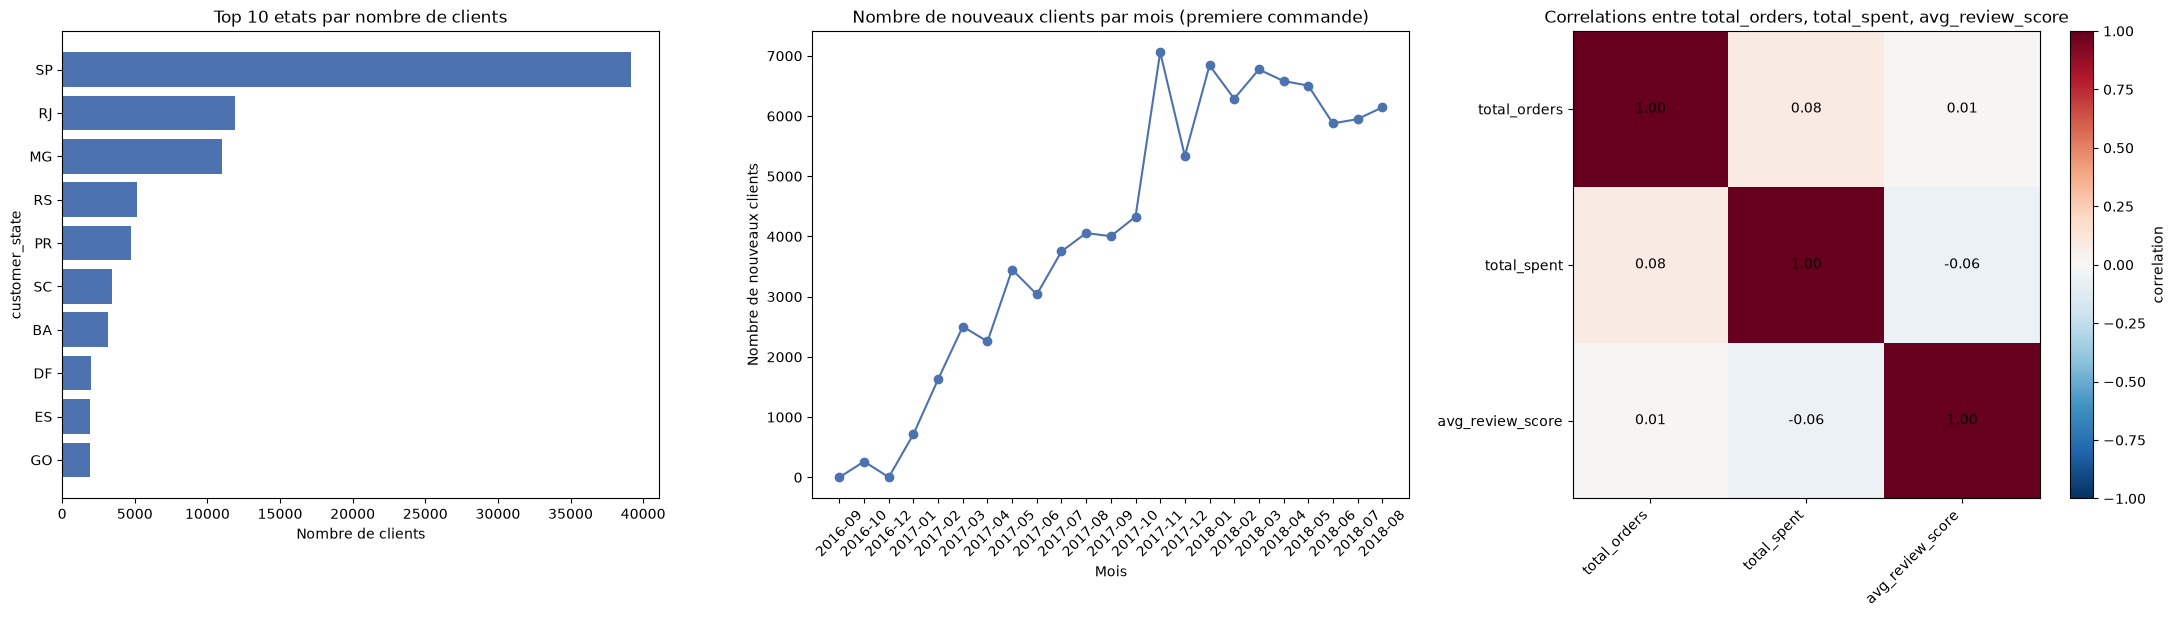

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
analysis.plot_clients_by_state(customers_df, ax=axes[0])
analysis.plot_orders_timeline(customers_df, ax=axes[1])
analysis.plot_correlation_matrix(customers_df, ax=axes[2])
plt.tight_layout()
plt.show()

## 7. Conclusions et decisions pour la suite

1. **La retention est quasi inexistante (97% des clients n'ont commande qu'une seule fois).** Le churn n'est pas un phenomene marginal ici : la Phase 5 doit traiter la variable churn comme le probleme central, pas comme une feature parmi d'autres.
2. **La depense (`total_spent`) est fortement asymetrique (log-normale).** Les features RFM de la Phase 5 devront etre construites (ou transformees, ex. log) en gardant cette asymetrie a l'esprit pour ne pas laisser les gros comptes dominer un modele lineaire.
3. **La geographie explique le volume de clients, pas leur valeur.** SP/RJ/MG concentrent la clientele mais la depense mediane par etat est comparable : `customer_state` est utile pour du reporting, moins prioritaire comme feature predictive forte de la valeur client.
4. **La satisfaction (`avg_review_score`) est globalement elevee et quasi decorrelee de `total_orders`.** Un bon score ne protege pas mecaniquement du churn : il faudra chercher les leviers de retention ailleurs (delai de livraison, recence, categorie) plutot que de compter sur la seule review.
5. **58.9% des clients ont une recency > 180 jours (seuil de churn deja defini dans `config.CHURN_THRESHOLD_DAYS`).** Ce chiffre confirme que le seuil retenu produit une classe churn majoritaire mais pas ecrasante — exploitable pour un modele de classification en Phase 5.
6. **`total_orders` et `total_spent` sont correles positivement, `avg_review_score` est quasi independant des deux.** Pour la Phase 5, ces deux premieres variables porteront probablement le plus de signal RFM, tandis que le score de review devra etre traite comme une feature complementaire plutot que redondante.